In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import re
# from google.colab import drive

In [7]:
# # 1. Mount Google Drive
# drive.mount('/content/drive')
#
# # 2. Setup Folder Paths
# folder = "/content/drive/MyDrive/Colab Notebooks"
# output_folder = "/content/drive/MyDrive/Colab Notebooks/Garmin sleep data/sleep_plots"
# os.makedirs(output_folder, exist_ok=True)

In [8]:
# 1. Ustawienie ścieżek
base_path = os.getcwd()
data_folder = os.path.join(base_path, "data")
output_folder = os.path.join(base_path, "sleep_plots")
os.makedirs(output_folder, exist_ok=True)

In [9]:
# 2. Pobranie list wszystkich plików zaczynających się od "Sleep-2026-03-06"
# Gwiazdka (*) zadziała jak "cokolwiek", czyli złapie końcówki "od 01", "od 02" itd.
pattern = os.path.join(data_folder, "Sleep-2026-03-06*.csv")
file_list = sorted(glob.glob(pattern))

if not file_list:
    print(f"Nie znaleziono plików w: {data_folder}. Sprawdź czy nazwy są poprawne.")
else:
    print(f"Znaleziono {len(file_list)} plików. Łączenie...")

    # 3. Wczytanie i połączenie plików w jeden DataFrame
    all_data = []
    for file in file_list:
        df = pd.read_csv(file)
        all_data.append(df)

    # Połączenie wszystkich tabel w jedną
    full_df = pd.concat(all_data, ignore_index=True)

    print("Sukces! Dane połączone.")
    print(f"Łączna liczba wierszy: {len(full_df)}")

    # Wyświetl pierwsze wiersze, żeby sprawdzić czy wszystko gra
    display(full_df.head())

Znaleziono 1 plików. Łączenie...
Sukces! Dane połączone.
Łączna liczba wierszy: 23


,Sleep Score 1 Day,Unnamed: 1
0,Date,2026-03-06
1,Sleep Duration,3h 11m
2,Sleep Score,41
3,Quality,Poor
4,Sleep Score Factors,NaN


Znaleziono 6 plików: ['Sleep-2026-03-01.csv', 'Sleep-2026-03-02.csv', 'Sleep-2026-03-03.csv', 'Sleep-2026-03-04.csv', 'Sleep-2026-03-05.csv', 'Sleep-2026-03-06.csv']

Przetworzone dane (podgląd):


,date_raw,deep_sleep,light_sleep,rem_sleep,sleep_score,avg_hr,hrv,spo2,date,date_str,total_sleep
0,2026-03-01,82,346,121,87,60,67,94,2026-03-01,01-03,549
1,2026-03-02,108,260,119,97,52,88,94,2026-03-02,02-03,487
2,2026-03-03,106,354,139,95,51,98,94,2026-03-03,03-03,599
3,2026-03-04,110,321,93,88,52,79,94,2026-03-04,04-03,524
4,2026-03-05,59,244,111,86,53,75,94,2026-03-05,05-03,414


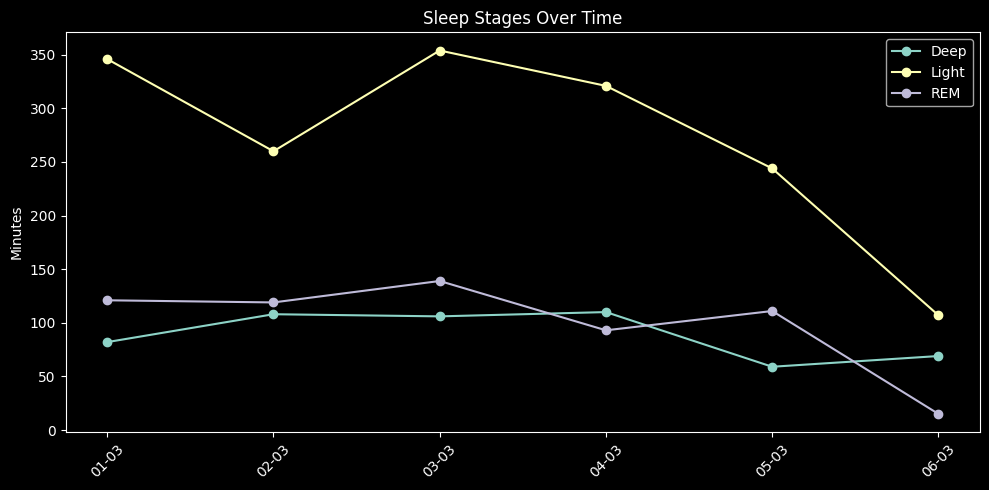

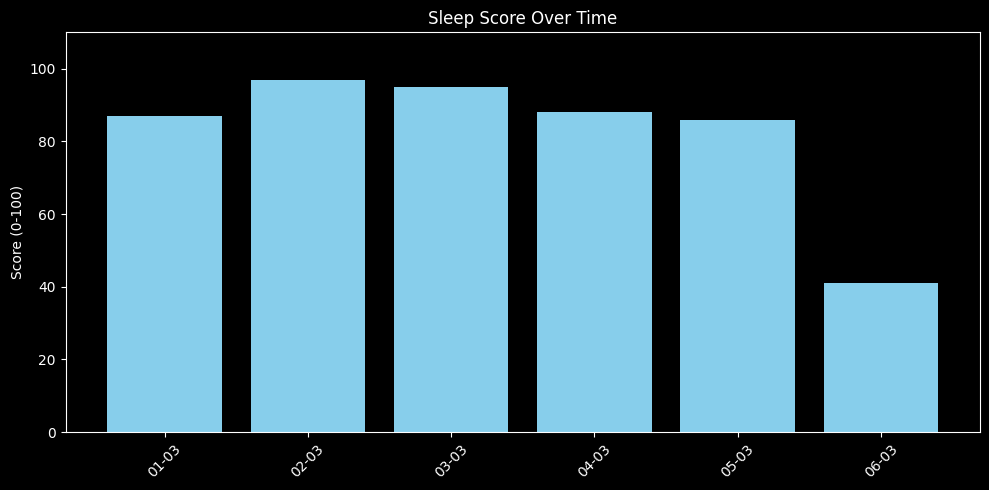

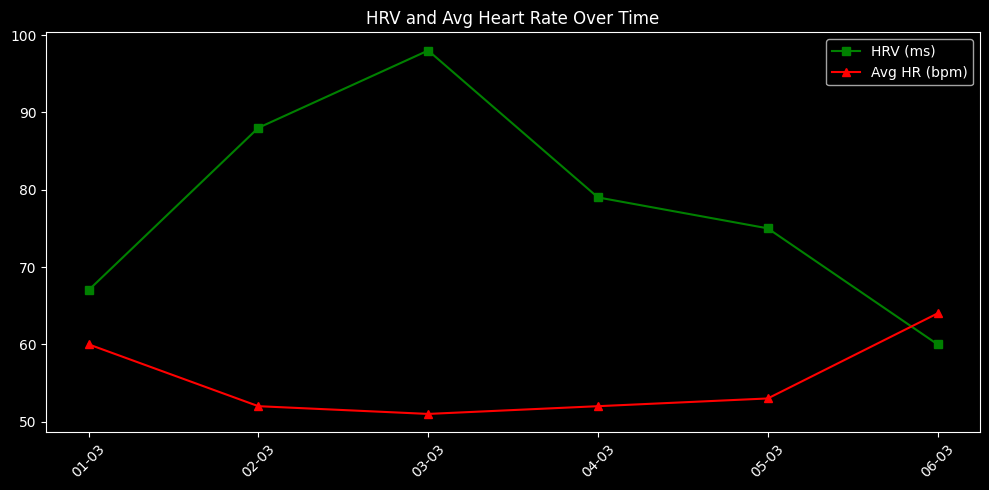

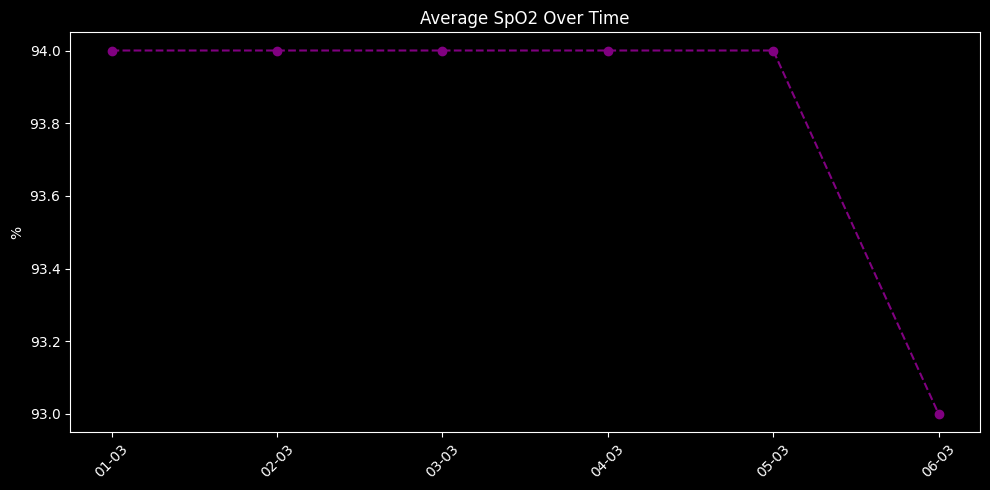

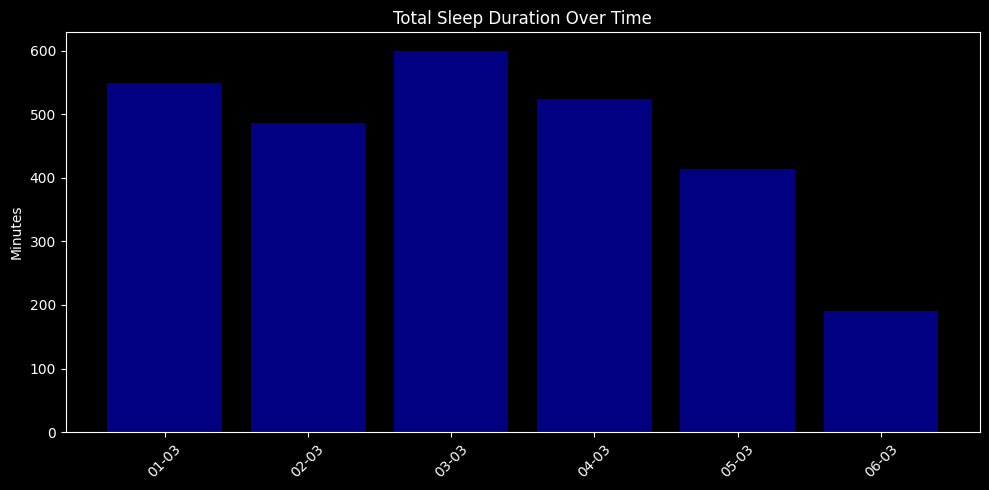


WSZYSTKIE WYKRESY ZOSTAŁY ZAPISANE W: /Users/maciejleszek/Desktop/it/bachelor/bachelor-thesis/sleep_plots


In [11]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. KONFIGURACJA ŚCIEŻEK ---
# Pobieramy aktualną lokalizację projektu
base_path = os.getcwd()
data_folder = os.path.join(base_path, "data")
output_folder = os.path.join(base_path, "sleep_plots")

# Tworzymy folder na wyniki, jeśli go nie ma
os.makedirs(output_folder, exist_ok=True)

# --- 2. FUNKCJE POMOCNICZE ---
def time_to_minutes(t):
    """Konwertuje format Garmina 'Xh Ym' na minuty."""
    if pd.isna(t) or t is None:
        return 0
    t_str = str(t)
    h = re.search(r'(\d+)h', t_str)
    m = re.search(r'(\d+)m', t_str)
    hours = int(h.group(1)) if h else 0
    minutes = int(m.group(1)) if m else 0
    return hours * 60 + minutes

# --- 3. FILTROWANIE I WCZYTYWANIE PLIKÓW ---
# Szukamy plików zaczynających się od "Sleep-" w folderze "data"
files = sorted([f for f in os.listdir(data_folder) if f.startswith("Sleep-") and f.endswith(".csv")])

if not files:
    print(f"BŁĄD: Nie znaleziono plików w {data_folder}. Sprawdź, czy pliki CSV tam są.")
else:
    print(f"Znaleziono {len(files)} plików: {files}")

    records = []
    for file in files:
        try:
            # Wczytanie pliku
            file_path = os.path.join(data_folder, file)
            df_temp = pd.read_csv(file_path)

            # Garmin często eksportuje dane jako dwie kolumny: Nazwa metryki | Wartość
            # Tworzymy z tego słownik dla łatwiejszego dostępu
            data_dict = dict(zip(df_temp.iloc[:, 0], df_temp.iloc[:, 1]))

            # Budowanie rekordu
            record = {
                # Pobieramy datę z nazwy (pierwsze 10 znaków po "Sleep-")
                "date_raw": file.replace("Sleep-", "")[:10],
                "deep_sleep": time_to_minutes(data_dict.get("Deep Sleep Duration")),
                "light_sleep": time_to_minutes(data_dict.get("Light Sleep Duration")),
                "rem_sleep": time_to_minutes(data_dict.get("REM Duration")),
                "sleep_score": int(data_dict.get("Sleep Score", 0)),
                "avg_hr": int(str(data_dict.get("Avg Overnight Heart Rate", "0")).split()[0]),
                "hrv": int(str(data_dict.get("Avg Overnight HRV", "0")).split()[0]),
                "spo2": int(str(data_dict.get("Avg SpO₂", "0")).replace("%", ""))
            }
            records.append(record)
        except Exception as e:
            print(f"Problem z plikiem {file}: {e}")

    # --- 4. PRZETWARZANIE DANYCH (Pandas) ---
    sleep_df = pd.DataFrame(records)

    # Konwersja daty i sortowanie chronologiczne
    sleep_df["date"] = pd.to_datetime(sleep_df["date_raw"], format="%Y-%m-%d")
    sleep_df = sleep_df.sort_values("date")

    # Dodatkowe kolumny do wykresów
    sleep_df["date_str"] = sleep_df["date"].dt.strftime("%d-%m")
    sleep_df["total_sleep"] = sleep_df["deep_sleep"] + sleep_df["light_sleep"] + sleep_df["rem_sleep"]

    print("\nPrzetworzone dane (podgląd):")
    display(sleep_df.head())

    # --- 5. GENEROWANIE WYKRESÓW ---

    # Wykres 1: Fazy snu
    plt.figure(figsize=(10, 5))
    plt.plot(sleep_df["date_str"], sleep_df["deep_sleep"], marker="o", label="Deep")
    plt.plot(sleep_df["date_str"], sleep_df["light_sleep"], marker="o", label="Light")
    plt.plot(sleep_df["date_str"], sleep_df["rem_sleep"], marker="o", label="REM")
    plt.title("Sleep Stages Over Time")
    plt.ylabel("Minutes")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "1_sleep_stages.png"))
    plt.show()

    # Wykres 2: Sleep Score
    plt.figure(figsize=(10, 5))
    plt.bar(sleep_df["date_str"], sleep_df["sleep_score"], color='skyblue')
    plt.title("Sleep Score Over Time")
    plt.ylabel("Score (0-100)")
    plt.ylim(0, 110)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "2_sleep_score.png"))
    plt.show()

    # Wykres 3: HRV vs Heart Rate
    plt.figure(figsize=(10, 5))
    plt.plot(sleep_df["date_str"], sleep_df["hrv"], marker="s", color='green', label="HRV (ms)")
    plt.plot(sleep_df["date_str"], sleep_df["avg_hr"], marker="^", color='red', label="Avg HR (bpm)")
    plt.title("HRV and Avg Heart Rate Over Time")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "3_hrv_vs_hr.png"))
    plt.show()

    # Wykres 4: SpO2
    plt.figure(figsize=(10, 5))
    plt.plot(sleep_df["date_str"], sleep_df["spo2"], marker="o", color='purple', linestyle='--')
    plt.title("Average SpO2 Over Time")
    plt.ylabel("%")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "4_spo2_levels.png"))
    plt.show()

    # Wykres 5: Sumaryczny czas snu
    plt.figure(figsize=(10, 5))
    plt.bar(sleep_df["date_str"], sleep_df["total_sleep"], color='navy')
    plt.title("Total Sleep Duration Over Time")
    plt.ylabel("Minutes")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "5_total_sleep.png"))
    plt.show()

    print(f"\nWSZYSTKIE WYKRESY ZOSTAŁY ZAPISANE W: {output_folder}")

Heatmap saved to: /Users/maciejleszek/Desktop/it/bachelor/bachelor-thesis/sleep_plots/6_sleep_correlation_heatmap.png


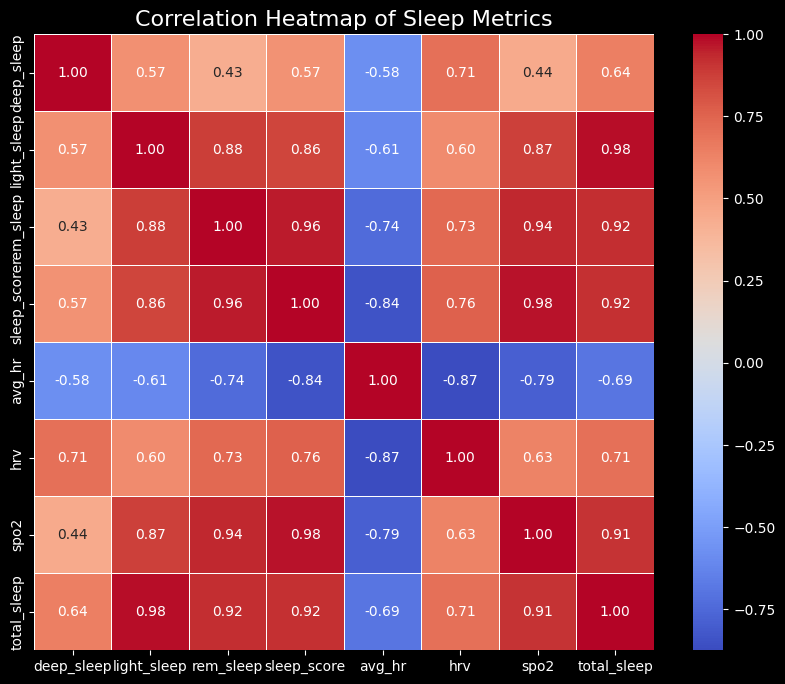

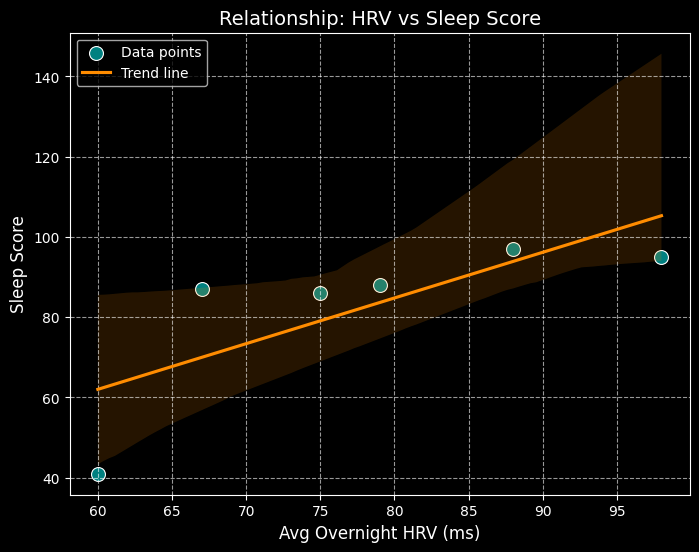

Scatter plot saved to: /Users/maciejleszek/Desktop/it/bachelor/bachelor-thesis/sleep_plots/7_hrv_vs_sleep_score.png


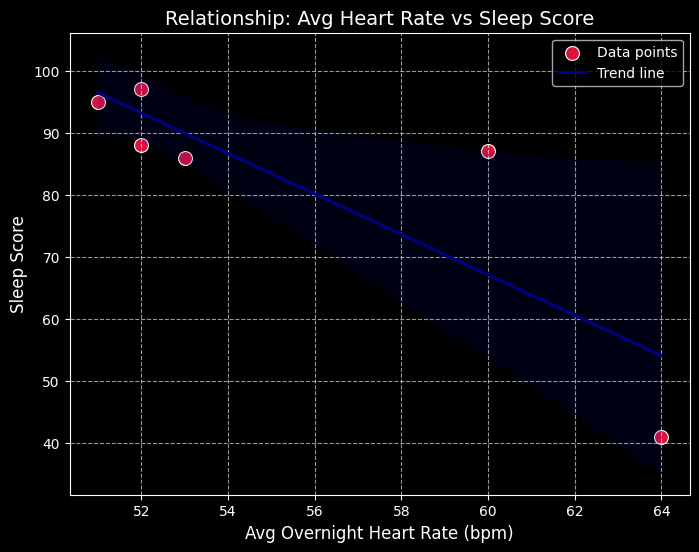

Scatter plot saved to: /Users/maciejleszek/Desktop/it/bachelor/bachelor-thesis/sleep_plots/8_hr_vs_sleep_score.png


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 8. ANALIZA KORELACJI (Heatmap) ---

# Wybieramy tylko kolumny numeryczne do korelacji
numeric_cols = ['deep_sleep', 'light_sleep', 'rem_sleep', 'sleep_score', 'avg_hr', 'hrv', 'spo2', 'total_sleep']
corr_matrix = sleep_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Sleep Metrics', fontsize=16)

# Zapisywanie przy użyciu os.path.join dla bezpieczeństwa
heatmap_path = os.path.join(output_folder, "6_sleep_correlation_heatmap.png")
plt.savefig(heatmap_path)
print(f"Heatmap saved to: {heatmap_path}")
plt.show()

# --- 9. RELACJE (Scatter Plots z Seaborn) ---

# 1. HRV vs Sleep Score Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sleep_df, x='hrv', y='sleep_score', s=100, color='teal', label='Data points')
sns.regplot(data=sleep_df, x='hrv', y='sleep_score', scatter=False, color='darkorange', label='Trend line')

plt.title('Relationship: HRV vs Sleep Score', fontsize=14)
plt.xlabel('Avg Overnight HRV (ms)', fontsize=12)
plt.ylabel('Sleep Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

save_path_hrv = os.path.join(output_folder, "7_hrv_vs_sleep_score.png")
plt.savefig(save_path_hrv)
plt.show()
print(f"Scatter plot saved to: {save_path_hrv}")

# 2. Avg HR vs Sleep Score Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sleep_df, x='avg_hr', y='sleep_score', s=100, color='crimson', label='Data points')
sns.regplot(data=sleep_df, x='avg_hr', y='sleep_score', scatter=False, color='navy', label='Trend line')

plt.title('Relationship: Avg Heart Rate vs Sleep Score', fontsize=14)
plt.xlabel('Avg Overnight Heart Rate (bpm)', fontsize=12)
plt.ylabel('Sleep Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

save_path_hr = os.path.join(output_folder, "8_hr_vs_sleep_score.png")
plt.savefig(save_path_hr)
plt.show()
print(f"Scatter plot saved to: {save_path_hr}")

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

# 1. Przygotowanie danych (używamy Twojego ramki sleep_df)
# Wybieramy parametry, które chcemy przewidzieć
target_cols = ['deep_sleep', 'light_sleep', 'rem_sleep', 'sleep_score', 'avg_hr', 'hrv', 'spo2']

# Tworzymy cechy (X) - dane z dnia poprzedniego (shift(1))
# Tworzymy cele (y) - dane z dnia dzisiejszego
df_model = sleep_df[target_cols].copy()

# Przesuwamy dane: dzisiejsze parametry będą przewidywane na podstawie wczorajszych
X = df_model.shift(1).dropna()
y = df_model.iloc[1:]

# 2. Podział na dane treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 3. Budowa modelu Multi-output
# Ponieważ chcemy przewidzieć wiele wartości na raz, używamy MultiOutputRegressor
model = MultiOutputRegressor(LinearRegression())
model.fit(X_train, y_train)

# 4. Ewaluacja
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions, multioutput='raw_values')

print("Średni błąd prognozy (MAE) dla poszczególnych parametrów:")
for col, error in zip(target_cols, mae):
    unit = "min" if "sleep" in col else "pkt/ms/bpm"
    print(f" - {col}: {error:.2f} {unit}")

# --- 5. PREDYKCJA NA JUTRO ---
# Bierzemy ostatni dostępny dzień z danych jako wejście
latest_data = df_model.iloc[-1:]
tomorrow_pred = model.predict(latest_data)

tomorrow_df = pd.DataFrame(tomorrow_pred, columns=target_cols)
print("\n--- PROGNOZA NA NASTĘPNĄ NOC ---")
display(tomorrow_df)

Średni błąd prognozy (MAE) dla poszczególnych parametrów:
 - deep_sleep: 62.87 min
 - light_sleep: 224.89 min
 - rem_sleep: 157.49 min
 - sleep_score: 68.03 min
 - avg_hr: 13.83 pkt/ms/bpm
 - hrv: 56.28 pkt/ms/bpm
 - spo2: 1.00 pkt/ms/bpm

--- PROGNOZA NA NASTĘPNĄ NOC ---


,deep_sleep,light_sleep,rem_sleep,sleep_score,avg_hr,hrv,spo2
0,35.222214,235.432064,234.836727,108.216372,51.200999,121.48458,94.0


In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# --- 1. PRZYGOTOWANIE DANYCH ---
target_cols = ['deep_sleep', 'light_sleep', 'rem_sleep', 'sleep_score', 'avg_hr', 'hrv']
df_model = sleep_df[target_cols].copy().dropna()

# X: dane z wczoraj, y: dane z dzisiaj
X_raw = df_model.shift(1).dropna()
y_raw = df_model.iloc[1:]

# Konwersja na macierze numpy
X_matrix = X_raw.values
y_matrix = y_raw.values

# Dodajemy kolumnę jedynek do X (tzw. bias/intercept), aby model mógł przesuwać linię w górę/dół
X_with_bias = np.c_[np.ones(X_matrix.shape[0]), X_matrix]

# --- 2. WŁASNA IMPLEMENTACJA (Normal Equation) ---
def train_manual_regression(X, y):
    # Zamiast inv (odwrotność), używamy pinv (pseudoodwrotność)
    # To rozwiązuje błąd "Singular matrix"
    theta = np.linalg.pinv(X.T @ X) @ X.T @ y
    return theta

# Teraz to zadziała nawet przy 6 dniach danych
theta_manual = train_manual_regression(X_with_bias, y_matrix)
print("Model ręczny wytrenowany pomyślnie przy użyciu pseudoodwrotności!")

# --- 3. IMPLEMENTACJA BIBLIOTECZNA (Scikit-learn) ---
sklearn_model = LinearRegression()
sklearn_model.fit(X_matrix, y_matrix)

# --- 4. PORÓWNANIE WYNIKÓW ---
# Wybieramy ostatni dzień, aby przewidzieć jutro
last_day = X_matrix[-1:]
last_day_with_bias = np.c_[np.ones(1), last_day]

# Predykcja ręczna
pred_manual = last_day_with_bias @ theta_manual

# Predykcja biblioteczna
pred_sklearn = sklearn_model.predict(last_day)

# Tworzymy tabelę porównawczą
comparison_df = pd.DataFrame({
    'Parametr': target_cols,
    'Moja Implementacja': pred_manual.flatten(),
    'Scikit-learn': pred_sklearn.flatten()
})

# Obliczamy różnicę (powinna być bliska zero)
comparison_df['Różnica'] = comparison_df['Moja Implementacja'] - comparison_df['Scikit-learn']

print("PORÓWNANIE PROGNOZY NA JUTRO:")
display(comparison_df)

# Sprawdzenie wag (Coefficients) dla pierwszego parametru (np. deep_sleep)
print(f"\nWagi dla {target_cols[0]} (pierwsze 3):")
print(f"Ręcznie: {theta_manual[1:4, 0]}")
print(f"Sklearn: {sklearn_model.coef_[0][:3]}")

Model ręczny wytrenowany pomyślnie przy użyciu pseudoodwrotności!
PORÓWNANIE PROGNOZY NA JUTRO:


,Parametr,Moja Implementacja,Scikit-learn,Różnica
0,deep_sleep,69.0,69.0,2.444267e-12
1,light_sleep,107.0,107.0,7.617018e-12
2,rem_sleep,15.0,15.0,3.495870e-12
3,sleep_score,41.0,41.0,2.614797e-12
4,avg_hr,64.0,64.0,1.108447e-12
5,hrv,60.0,60.0,2.103206e-12



Wagi dla deep_sleep (pierwsze 3):
Ręcznie: [ 1.0802617  -0.21790345  2.21091434]
Sklearn: [ 0.76860557 -0.14958423  1.79387386]
